# 01. Circuit Discovery

        This notebook demonstrates the **discovery phase** of the project.

        In mechanistic interpretability terms, this phase asks:
        - Where in the model does the malicious-vs-benign decision start to appear?
        - Which attention heads repeatedly focus on suspicious PowerShell indicators?
        - Which later layers look like they carry the decision toward the final `BLOCK` or `ALLOW` output?

        In plain language, the question is:
        - What parts of the model seem to notice risky code patterns early?
        - What parts of the model seem to turn those early clues into a final judgment later?

        This notebook is **CPU-friendly by default**. It reads the artifact files produced by the main analysis pipeline and uses plots to explain the methodology and the results.


In [ ]:
from pathlib import Path
import math
import sys
import textwrap

import circuitsvis as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display

plt.style.use("ggplot")
sns.set_context("talk")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scaled_validation import (
    DEFAULT_MODEL_NAME,
    build_hooked_transformer,
    load_hf_model_and_tokenizer,
    make_prompt,
)


NOTEBOOK_MODEL_NAME = DEFAULT_MODEL_NAME
NOTEBOOK_TEMPLATE_NAME = "meta-llama/Llama-3.1-8B-Instruct"
NOTEBOOK_DEVICE = "cpu"
NOTEBOOK_TORCH_DTYPE = "float32"
_MODEL_BUNDLE = None


def read_csv(name: str) -> pd.DataFrame:
    path = ARTIFACTS / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_barh(df, label_col, value_col, *, title, xlabel, color="#2B6CB0", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(plot_df))))
    ax.barh(plot_df[label_col], plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    return fig, ax


def get_notebook_model():
    global _MODEL_BUNDLE
    if _MODEL_BUNDLE is None:
        hf_model, tokenizer, device = load_hf_model_and_tokenizer(
            NOTEBOOK_MODEL_NAME,
            device=NOTEBOOK_DEVICE,
            torch_dtype=NOTEBOOK_TORCH_DTYPE,
        )
        model = build_hooked_transformer(
            hf_model,
            tokenizer,
            device=device,
            torch_dtype=NOTEBOOK_TORCH_DTYPE,
            template_name=NOTEBOOK_TEMPLATE_NAME,
            use_attn_result=False,
        )
        model.eval()
        _MODEL_BUNDLE = (model, tokenizer, device)
    return _MODEL_BUNDLE


def get_pair_rows(manifest: pd.DataFrame, pair_idx: int):
    group = manifest[manifest["pair_idx"] == pair_idx].copy()
    if group.empty:
        raise KeyError(f"pair_idx={pair_idx} was not found in the manifest")
    benign_row = group[group["pair_role"] == "benign"].iloc[0]
    malicious_row = group[group["pair_role"] == "malicious"].iloc[0]
    return benign_row, malicious_row


def run_prompt_with_cache(script_text: str):
    model, tokenizer, device = get_notebook_model()
    prompt = make_prompt(str(script_text))
    toks = model.to_tokens(prompt)
    logits, cache = model.run_with_cache(toks, return_type="logits")
    return model, tokenizer, toks, logits, cache


def toks_to_str_tokens_strict(model, toks):
    """
    toks: [1, seq] or [seq] int64 token IDs
    returns list[str] length == seq
    """
    toks_1d = toks[0] if toks.ndim == 2 else toks
    ids = [int(x) for x in toks_1d.detach().cpu().tolist()]

    tok = getattr(model, "tokenizer", None)
    if tok is None:
        raise ValueError("model.tokenizer is None; can't convert ids->tokens reliably.")

    return tok.convert_ids_to_tokens(ids)


def print_key_tokens_for_head(cache, model, toks, layer, head, query_pos=-1, topk=25):
    patt = cache[f"blocks.{layer}.attn.hook_pattern"][0]
    seq_len = patt.shape[-1]

    str_toks = toks_to_str_tokens_strict(model, toks)
    assert len(str_toks) == seq_len, (len(str_toks), seq_len)

    attn = patt[head, query_pos, :]
    vals, idx = torch.topk(attn, k=min(topk, seq_len))

    print(f"Top key positions for layer={layer}, head={head}, query_pos={query_pos}:")
    for i, v in zip(idx.detach().cpu().tolist(), vals.detach().cpu().tolist()):
        print(f"  k={i:3d}  attn={float(v):0.6f}  tok={repr(str_toks[i])}")


def most_attended_key_columns(cache, model, toks, layer, head, topk_per_query=5, max_out=30):
    patt = cache[f"blocks.{layer}.attn.hook_pattern"][0]
    seq_len = patt.shape[-1]
    str_toks = toks_to_str_tokens_strict(model, toks)
    assert len(str_toks) == seq_len, (len(str_toks), seq_len)

    hits = np.zeros(seq_len, dtype=np.int64)
    for q in range(seq_len):
        attn_q = patt[head, q, :]
        _, idx = torch.topk(attn_q, k=min(topk_per_query, seq_len))
        for i in idx.detach().cpu().tolist():
            hits[i] += 1

    top_idx = np.argsort(-hits)[:max_out]
    print(f"Most frequently attended key columns (vertical stripes proxy) for layer={layer}, head={head}:")
    for i in top_idx:
        print(f"  k={i:3d}  hits={int(hits[i]):3d}  tok={repr(str_toks[i])}")


def render_single_head_pattern(cache, model, toks, layer, head):
    str_toks = toks_to_str_tokens_strict(model, toks)
    head_pattern = cache[f"blocks.{layer}.attn.hook_pattern"][0, head : head + 1].detach().cpu().numpy()
    return cv.attention.attention_patterns(
        attention=head_pattern,
        tokens=str_toks,
        attention_head_names=[f"L{layer}H{head}"],
    )


## Step 1: Load the discovery artifacts

        We use two main artifact families here:
        - an **attention recurrence summary** that ranks heads by how often they focus on suspicious indicator tokens
        - a **full-model layer ablation summary** that shows which attention and MLP blocks matter most when they are removed

        Together, these tell a coherent story:
        - early attention heads do pattern detection
        - later layers do decision consolidation


In [ ]:
attention_summary = read_csv("circuit_val_batch_attention_l4_n18_h100_summary.csv")
causal_ablation = read_csv("circuit_val_batch_causal_root_l4_n18short_h100_ablation_summary.csv")
pair_manifest = read_csv("circuit_val_pair_manifest_t3000_valid_causal18_short_h100.csv")
layer_ablation = read_csv("circuit_val_layer_ablation_full_h100_summary.csv")

attention_summary.head(10)


## Step 2: Identify the early detector heads

        The chart below ranks the most recurrent heads in the short overlap-controlled cohort.

        Technical interpretation:
        - a larger `mean_attention_delta` means the head attends more strongly to suspicious indicator positions than to matched random control positions

        Non-jargon interpretation:
        - these are the heads that most consistently "look at the suspicious parts" of the script


In [ ]:
top_heads = attention_summary.head(10).copy()
top_heads["head_label"] = top_heads.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)
show_barh(
    top_heads,
    "head_label",
    "mean_attention_delta",
    title="Top Recurrent Heads by Attention to Suspicious Indicators",
    xlabel="Mean attention delta",
    color="#C05621",
    sort=True,
)
plt.show()

top_heads[["head_label", "pair_count", "mean_attention_delta", "max_attention_delta"]]

causal_heads = causal_ablation.sort_values(["mean_delta", "flip_rate"], ascending=[True, False]).copy()
causal_heads["head_label"] = causal_heads.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)
causal_plot = causal_heads.assign(causal_strength=lambda df: -df["mean_delta"])
show_barh(
    causal_plot,
    "head_label",
    "causal_strength",
    title="Top Causal Early Heads by Ablation Effect",
    xlabel="- mean_delta (larger = stronger causal drop)",
    color="#2F855A",
    sort=True,
)
plt.show()

causal_heads[["head_label", "pair_count", "mean_delta", "flip_rate"]]


## Step 2b: Interactive view of the strongest causal head

This section replaces the placeholder token-coloring example with a real `circuitsvis` attention plot for one of the strongest **causal** early heads.

It loads a single malicious script from the validated 18-pair cohort, runs one forward pass with caching, and then shows:

- the selected head's full attention pattern
- the top key tokens for the final query position
- the key columns that attract attention across many query positions

This cell is heavier than the artifact-only cells above because it loads the local model and a single TransformerLens cache on CPU by default.


In [ ]:
top_row = causal_heads.iloc[0]
TOP_LAYER = int(top_row["layer"])
TOP_HEAD = int(top_row["head"])
DISCOVERY_PAIR_IDX = int(pair_manifest.loc[pair_manifest["pair_role"].eq("malicious"), "pair_idx"].iloc[0])

_, discovery_mal_row = get_pair_rows(pair_manifest, DISCOVERY_PAIR_IDX)
model, tokenizer, mal_toks, mal_logits, mal_cache = run_prompt_with_cache(discovery_mal_row["content"])

print(f"Top causal head: layer={TOP_LAYER}, head={TOP_HEAD}")
print(f"Example pair_idx={DISCOVERY_PAIR_IDX}, file={discovery_mal_row['filename']}")
print(
    "Malicious script preview:",
    textwrap.shorten(str(discovery_mal_row["content"]).replace("\n", " "), width=180, placeholder=" ..."),
)

display(render_single_head_pattern(mal_cache, model, mal_toks, TOP_LAYER, TOP_HEAD))
print_key_tokens_for_head(mal_cache, model, mal_toks, TOP_LAYER, TOP_HEAD, query_pos=-1, topk=20)
most_attended_key_columns(mal_cache, model, mal_toks, TOP_LAYER, TOP_HEAD, topk_per_query=5, max_out=20)


## Step 3: Localize the later decision stage

        Head-level attention is only part of the story. We also want to know where the model becomes **causally fragile**:
        if we remove a whole layer component, how much does the malicious-vs-benign logit move?

        We split the ablation results into:
        - **attention components**: token-to-token communication
        - **MLP components**: feedforward transformations inside each block


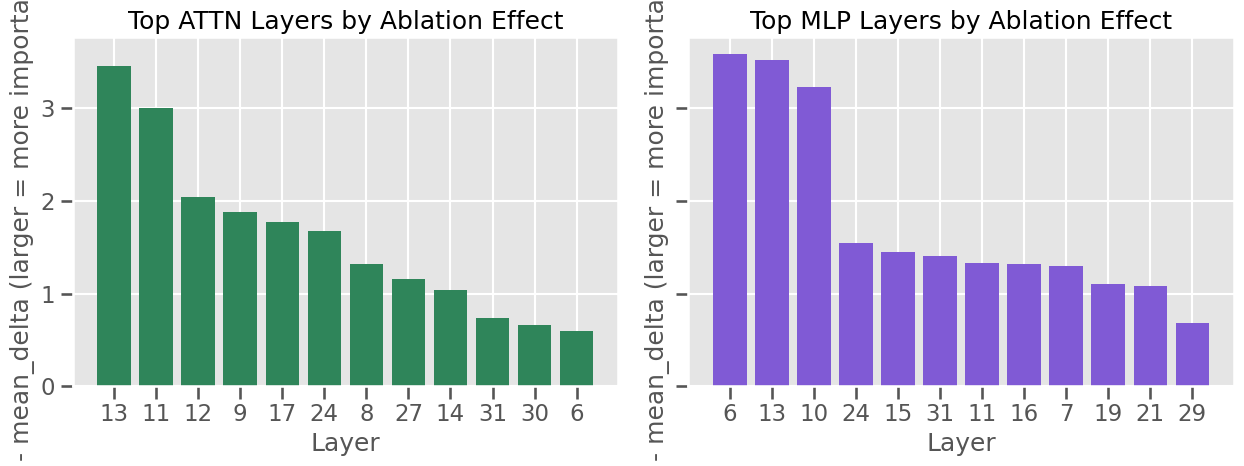

,layer,component,pair_count,mean_delta,max_delta,min_delta,flip_rate,mean_base_logit_diff
32,6,mlp,18,-3.587674,-0.234375,-8.109375,0.388889,3.924479
33,13,mlp,18,-3.518663,-0.921875,-5.609375,0.611111,3.924479
0,13,attn,18,-3.453125,-0.546875,-5.359375,0.500000,3.924479
34,10,mlp,18,-3.234375,-0.593750,-8.109375,0.444444,3.924479
1,11,attn,18,-3.006076,1.203125,-6.828125,0.333333,3.924479
2,12,attn,18,-2.037326,0.656250,-5.656250,0.111111,3.924479
3,9,attn,18,-1.880208,2.593750,-5.703125,0.111111,3.924479
4,17,attn,18,-1.773438,0.015625,-5.062500,0.055556,3.924479
5,24,attn,18,-1.675347,-0.937500,-2.593750,0.277778,3.924479
35,24,mlp,18,-1.549913,-0.359375,-2.726562,0.277778,3.924479


In [5]:
ablation_plot = layer_ablation.copy()
ablation_plot["signed_effect"] = -ablation_plot["mean_delta"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, component, color in zip(axes, ["attn", "mlp"], ["#2F855A", "#805AD5"]):
    subset = ablation_plot[ablation_plot["component"] == component].sort_values("signed_effect", ascending=False).head(12)
    ax.bar(subset["layer"].astype(str), subset["signed_effect"], color=color)
    ax.set_title(f"Top {component.upper()} Layers by Ablation Effect")
    ax.set_xlabel("Layer")
    ax.set_ylabel("- mean_delta (larger = more important)")
plt.tight_layout()
plt.show()

layer_ablation.sort_values("mean_delta").head(12)


## Step 4: Interpret the discovery phase

        The discovery phase supports a two-stage circuit hypothesis:

        1. **Early detection**
           Heads in `Layer 0`, especially `L0H11` and `L0H9`, repeatedly focus on suspicious PowerShell indicators such as `IEX`, `DownloadString`, `Invoke-WebRequest`, and `-EncodedCommand`.

        2. **Late decision consolidation**
           A later band, especially `Layer 12-13` attention and a broader MLP band, appears to carry and refine the final malicious-vs-benign decision.

        This does **not** yet prove causality by itself. It tells us where to intervene next. That is the purpose of the validation notebook.


## Optional: Lightweight recomputation notes

        If you want to rerun small parts of the discovery workflow locally, use `scaled_validation.py`.
        The heavier model-intervention runs are better on GPU, but the artifact-reading workflow in this notebook is designed to work comfortably on CPU.


In [6]:
# Example only. Uncomment to run a small discovery command locally.
#
# !python ../scaled_validation.py batch-discover-heads \
#     --manifest ../artifacts/circuit_val_pair_manifest_t3000_valid_causal18_short.csv \
#     --device cpu \
#     --torch-dtype float32 \
#     --num-pairs 2 \
#     --first-n-layers 4 \
#     --output-prefix ../artifacts/demo_discovery_cpu
